# Least Squares Solution for a simple 2d regression problem

In this exercise you will see how we can implement the dual representation of the least squares and apply them on synthetic data. The benefit is that we will see how the different coefficient used to create the data, will surface as the weights of the least squares and you will see that both have exactly the same solution. In addition we will see how the noise will affect the exactness of the final solution that the least squares can produce.


**Learning Outcomes**

1. Implement the dual representation of the least square solution using numpy only
2. Apply the implemented solution on a synthetic data and examine the resultant weights


In [1]:
%matplotlib inline

In [2]:
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
import pandas as pd
import time

generate the data

In [3]:
def get_t(Φ, w_):
    w_ = np.array(w_)
    return  (Φ.dot(w_)).T

In [4]:
def generateData(w_, noise=0, n = 1000 ):
    ϕ0 = np.ones((n,))                             # the intercept
    ϕ1 = np.linspace(-10, 10, num = n)             # this sampling uniformly from the x axis
    ϕ2 = np.random.normal(ϕ1,5)                    # same but some noise to avoid matrix Φ singularity for Φ^-1
    
    Φ  = np.array([ϕ0, ϕ1, ϕ2]).T                  # design matrix with intercept
    
    t  = get_t(Φ, w_)                              # get the target value
    t  = np.random.normal(t,noise)                 # add noise to the target to see the effect on the MSE
    
    return Φ,t

## Generate the data first

In [5]:

w_    = np.array([10, 2, 5]).T   # original model weights to generate the data from and to compare later with w
noise = 5
num   = 5000                     # try increase num to see how long it will take to find the solution
Φ,t   = generateData(w_, noise=noise, n=num)    # try with and without noise

print(Φ.shape)
print(t.shape)

(5000, 3)
(5000,)


## Dual Least Squares Solutions with Regularisation 

In [6]:
def getRegLS(Φ,t, kernel=False, λ=0.000001):     
    # Standard and kernel Least Squares Solution! λ is a regularisation constant
    # note that this is computaitonally much more expensive than the standard least squares
    if kernel==False:
        
        ΦTt = Φ.T.dot(t)
        ΦTΦ = Φ.T.dot(Φ)
        ΦTΦ = inv(ΦTΦ + λ*np.eye((ΦTΦ.shape[0])))
        print('ΦTΦ dim    = ',ΦTΦ.shape)
        w = ΦTΦ.dot(ΦTt)
    else:
        ΦT   = Φ.T
        ΦΦT  = Φ.dot(ΦT)
        ΦΦT  = inv(ΦΦT + λ*np.eye((ΦΦT.shape[0])))
        ΦΦTt = ΦΦT.dot(t)
        print('ΦΦT dim    =',ΦΦT.shape)
        w  = ΦT.dot(ΦΦTt)
    return w

## Now apply the Least Squares on the Generated Dataset

Now let us try it ......................!

In [7]:
def applyLST(Φ,t, kernel=False):
    start = time.time()
    
    w   = getRegLS(Φ, t, kernel)                   # solve using standard and kernel least squares
    y   = get_t   (Φ, w)                           # predict using the solution
    
    tm_exec = np.round(time.time() - start,5)
    
    RMSE = np.sqrt(((t - y)**2).sum()/len(t))       # get the Sqrt(Mean Sum of Squared Error)
    
    if kernel==False: print('standard w  =',w)
    else:             print('kernel w    =',w)
    print('method time = ', tm_exec,'sec \n')
    
    return y, w, RMSE


y, w, RMSE = applyLST(Φ,t)               # standard  least squares
y, w, RMSE = applyLST(Φ,t, kernel=True)  # kernel    least squares


ΦTΦ dim    =  (3, 3)
standard w  = [9.92796457 2.01330188 4.99437326]
method time =  0.01048 sec 

ΦΦT dim    = (5000, 5000)
kernel w    = [9.92796914 2.01329139 4.994349  ]
method time =  2.83883 sec 



Note how both solutions are identical. The standard least squares is of course more efficient than the kernel least squares. The efficiency here is a side issue though, our concern is regarding the equivalency, other kernel methods can be more efficient than kernel least squares.

## Now compare 
between the fitted model wieghts and the original wieghts used to creat the dataset (remember we added noise so there is no prefect solution)

In [8]:
print(w)
print(w_)
print('RMSE',np.round(RMSE,2))
print(noise)                                
# note how RMSE is close to the noise (when data is enough < 300 and for reasonable noise values)

[9.92796914 2.01329139 4.994349  ]
[10  2  5]
RMSE 5.05
5


## Visualise 
both attributes x1 and x2 in 2d, we may want to create a better visualisation by plotting in 3d (x1, x2, y)

Below we can realise that although Least squares is an exact solution (for the given data), the two lines may differ due to the added noise and not due to approximation.

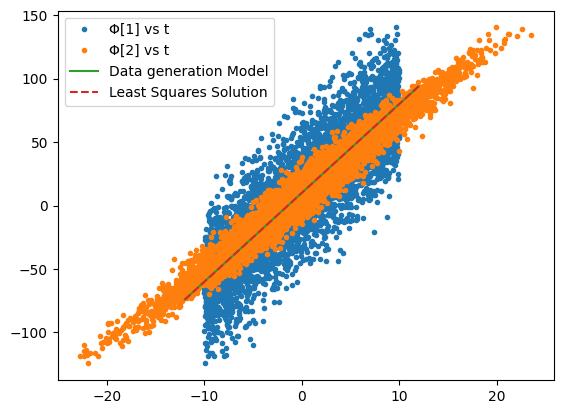

In [9]:
plt.plot(Φ.T[1],t,'.', label='Φ[1] vs t')
plt.plot(Φ.T[2],t,'.', label='Φ[2] vs t')

x1 = np.linspace(-12, 12, num = 10)
Φ1 = np.array([np.ones(len(x1)), x1, x1]).T

plt.plot(x1, get_t( Φ1, w_),'-' , label='Data generation Model')
plt.plot(x1, get_t( Φ1, w ),'--', label='Least Squares Solution')
plt.legend()
